In [1]:
from google.colab import drive
import zipfile
import os

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
dataset_path ="/content/drive/MyDrive/archive_cat_dog.zip"

In [4]:
with zipfile.ZipFile(dataset_path, 'r') as zip_ref:
    zip_ref.extractall('/content/cat_dog_dataset')

In [5]:
data_dir ='/content/cat_dog_dataset'

In [6]:
print("Files in dataset folder:", os.listdir(data_dir))

Files in dataset folder: ['test_set', 'training_set']


In [7]:
import tensorflow as tf
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

In [8]:
# Define AlexNet Architecture
model = Sequential([
    Conv2D(96, (11, 11), strides=4, activation='relu', input_shape=(224, 224, 3)),
    MaxPooling2D(pool_size=(3, 3), strides=2),

    Conv2D(256, (5, 5), activation='relu', padding="same"),
    MaxPooling2D(pool_size=(3, 3), strides=2),

    Conv2D(384, (3, 3), activation='relu', padding="same"),
    Conv2D(384, (3, 3), activation='relu', padding="same"),
    Conv2D(256, (3, 3), activation='relu', padding="same"),
    MaxPooling2D(pool_size=(3, 3), strides=2),

    Flatten(),
    Dense(4096, activation='relu'),
    Dropout(0.5),
    Dense(4096, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')  # Binary classification (Cat vs. Dog)
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [10]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 54, 54, 96)          │          34,944 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 26, 26, 96)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 26, 26, 256)         │         614,656 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 12, 12, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 12, 12, 384)         │         885,120 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 12, 12, 384)         │       1,327,488 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 12, 12, 256)         │         884,992 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 5, 5, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 6400)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 4096)                │      26,218,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 4096)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 4096)                │      16,781,312 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 4096)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │           4,097 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 46,751,105 (178.34 MB)

 Trainable params: 46,751,105 (178.34 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
train_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)  # 20% for validation
test_datagen = ImageDataGenerator(rescale=1./255)

In [13]:
train_generator = train_datagen.flow_from_directory(
    '/content/cat_dog_dataset/training_set/training_set',  # Path to training data
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

Found 6404 images belonging to 2 classes.


In [14]:
val_generator = train_datagen.flow_from_directory(
    '/content/cat_dog_dataset/training_set/training_set',
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)

Found 1601 images belonging to 2 classes.


In [15]:
test_generator = test_datagen.flow_from_directory(
    '/content/cat_dog_dataset/test_set/test_set',  # Path to test data
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

Found 2023 images belonging to 2 classes.


In [16]:
epochs = 10
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=epochs
)

Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


201/201 ━━━━━━━━━━━━━━━━━━━━ 34s 121ms/step - accuracy: 0.4925 - loss: 0.9363 - val_accuracy: 0.4997 - val_loss: 0.6931
Epoch 2/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 26s 79ms/step - accuracy: 0.4860 - loss: 0.6935 - val_accuracy: 0.5003 - val_loss: 0.6932
Epoch 3/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 24s 94ms/step - accuracy: 0.5033 - loss: 0.6936 - val_accuracy: 0.5003 - val_loss: 0.6932
Epoch 4/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 17s 81ms/step - accuracy: 0.4948 - loss: 0.6938 - val_accuracy: 0.5003 - val_loss: 0.6931
Epoch 5/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 16s 80ms/step - accuracy: 0.5024 - loss: 0.6933 - val_accuracy: 0.4997 - val_loss: 0.6932
Epoch 6/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 21s 81ms/step - accuracy: 0.4943 - loss: 0.6934 - val_accuracy: 0.4997 - val_loss: 0.6932
Epoch 7/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 16s 80ms/step - accuracy: 0.4956 - loss: 0.6933 - val_accuracy: 0.4997 - val_loss: 0.6932
Epoch 8/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 17s 82ms/step - accuracy: 0.5028 - loss: 0.6933 - val_accura

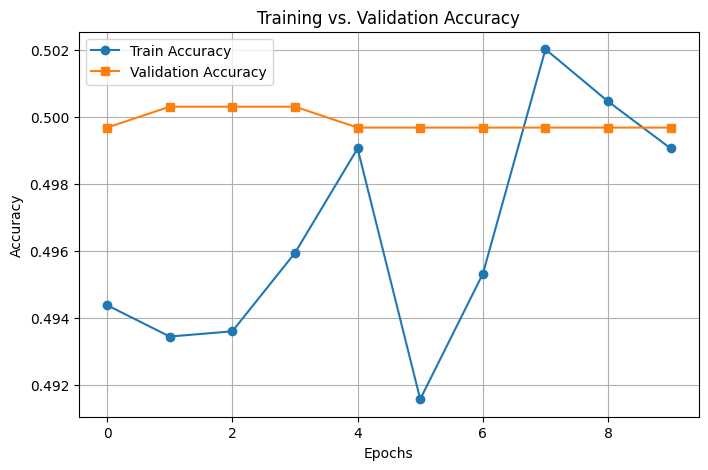

In [17]:
# Plot Training & Validation Accuracy
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Train Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='s')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs. Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [18]:
test_loss, test_acc = model.evaluate(test_generator)
print(f"Test accuracy: {test_acc:.4f}")

64/64 ━━━━━━━━━━━━━━━━━━━━ 5s 76ms/step - accuracy: 0.8330 - loss: 0.6894
Test accuracy: 0.4998
